# Bjerknes feedback changes over time

## imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import xarray as xr
import tqdm
import pathlib
import cmocean
import os
import copy
import time

# Import custom modules
import src.utils

## set plotting specs
sns.set(rc={"axes.facecolor": "white", "axes.grid": False})

## bump up DPI
mpl.rcParams["figure.dpi"] = 100

## get filepaths
DATA_FP = pathlib.Path(os.environ["DATA_FP"])
SAVE_FP = pathlib.Path(os.environ["SAVE_FP"])

## Funcs

### Misc

In [2]:
def window(x):
    return src.utils.get_windowed(x, stride=120)


def load_consolidated_wide():
    """utility function to load consolidated data"""

    ## directory with data
    CONS_DIR = pathlib.Path(os.environ["DATA_FP"], "cesm", "consolidated_05")

    ## function to align and open
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    align_and_open = lambda fp: src.utils.align_pop_times(xr.open_dataset(fp), **kwargs)

    ## open data and align pop times
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    forced = align_and_open(CONS_DIR / "forced.nc")
    anom = align_and_open(CONS_DIR / "anom.nc")

    return forced, anom


def regress_over_time(data, x_vars, y_vars, dims=["time", "member"]):
    """regression over time"""

    ## get windowed data
    data_ = window(data)

    ## empty list to hold coefficients
    coefs = []

    ## shared args
    kwargs = dict(x_vars=x_vars, y_vars=y_vars, dims=dims)

    ## loop thru years
    for year in tqdm.tqdm(data_.year):

        ## get grouped data
        data_y = data_.sel(year=year).groupby("time.month")

        ## do regression
        coefs.append(data_y.map(src.utils.regress_xr_proj, **kwargs))

    return xr.concat(coefs, dim=data_.year)


def regress_wrapper(data, x_vars, y_var, y_fn, dims=["time", "member"]):
    """regression over time"""

    ## prep data
    y_data = src.utils.reconstruct_wrapper(data[[f"{y_var}", f"{y_var}_comp"]], fn=y_fn)

    ## subset for data
    data_ = xr.merge([data[x_vars], y_data])

    return regress_over_time(data_, x_vars=x_vars, y_vars=[y_var], dims=dims)


def frac_change(x):
    """fractional change"""
    return x / x.isel(year=0) - 1

def check_dims(x):
    """make sure dimensions are ok before averaging"""
    ## check if latitude is in ssh
    if "latitude" in x.dims:
        x_ = copy.deepcopy(x)
    else:
        x_ = x.expand_dims("latitude")

    ## check if z_t is in ssh
    if "z_t" in x.dims:
        x_ = copy.deepcopy(x_)
    else:
        x_ = x_.expand_dims("z_t")

    return x_

### Plotting

In [3]:
def make_scatter_ax(ax, anom_, xvar, yvar, month, label, by_season=True):
    """scatter plot of data for given month"""

    ## prep func
    if by_season:
        get_season = lambda x: src.utils.sel_month(
            x.resample({"time": "QS-JAN"}).mean(), month
        )

    else:
        get_season = lambda x: src.utils.sel_month(x, month)

    prep = lambda x: get_season(x).transpose("time", "member")

    ## get plot data
    plot_data = (prep(anom_[xvar]), prep(anom_[yvar]))

    ## get stats
    corr = xr.corr(*plot_data)
    cov = xr.cov(*plot_data)
    m = cov / plot_data[0].var()

    ## plot data
    ax.scatter(*plot_data, s=3, label=f"m = {m.item():.1e}\nr = {corr.item():.2f}")
    ax.set_title(f"{label}")

    ## formatting
    ax_kwargs = dict(ls="--", c="gray", lw=0.5)
    ax.axvline(0, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    ax.legend(prop=dict(size=10))

    return ax


def make_scatter(anom_, xvar, yvar, month, by_season=True):
    """scatter plot of data for given month"""

    fig, axs = plt.subplots(1, 4, figsize=(11, 2.5), layout="constrained")

    for ax, t_idx, label in zip(
        axs,
        [["1850", "1879"], ["1995", "2024"], ["2035", "2064"], ["2071", "2100"]],
        ["1865", "2010", "2050", "2085"],
    ):

        ## helper func
        prep = lambda x: x.sel(time=slice(*t_idx))

        ## scatter plot of data
        ax = make_scatter_ax(
            ax,
            prep(anom_),
            xvar=xvar,
            yvar=yvar,
            month=month,
            by_season=by_season,
            label=label,
        )

    ## format/scale axes
    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])

    return fig, axs

def plot_timeseries(coefs, sel_fn):
    """plot timeseries comparison"""

    fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

    ## loop thru pos and negative
    for i, (name, color) in enumerate(zip(["pos", "neg"], ["r", "b"])):

        ## plot neutral and pos/or neg
        for name_, color_ in zip(["all", name], ["k", color]):

            ## plot median and bounds
            for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

                ## finally, plot data
                axs[i].plot(
                    coefs.year,
                    sel_fn(coefs)[name_].quantile(q=q, dim="member"),
                    c=color_,
                    lw=lw,
                )

    ## formatting
    for ax in axs:
        ax.set_xticks([1870, 2010, 2080])
        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        ax.axvline(2010, **ax_kwargs)
        ax.axhline(0, **ax_kwargs)
    src.utils.set_lims(axs)
    axs[1].set_yticks([])

    return fig, axs


def plot_zonal_structure(coefs, sel_fn):
    """plot zonal structure of coefficients over time"""

    fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

    for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

        ## get data for year
        ax.set_title(y)
        coefs_y = sel(coefs).sel(year=y, method="nearest")

        ## select data
        for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

            ax.plot(coefs.longitude, coefs_y[n].mean("member"), c=color)

    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])

    for ax in axs:
        ax.set_xticks([140, 190, 240, 280])
        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        ax.axhline(0, **ax_kwargs)

    return fig, axs


def add_vticks(axs, xticks, xlines=None):
    """add vertical lines to axs"""

    ## specify line style
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)

    ## loop thru axs
    for ax in axs:
        ax.set_xticks(xticks)
        if xlines is not None:
            for x0 in xlines:
                ax.axvline(x0, **ax_kwargs)

    return

## Load data

#### $T$, $h$

In [4]:
## open data
Th = src.utils.load_cesm_indices(load_z20=True)

### Spatial data

#### most data

In [5]:
## load spatial data
forced, anom = src.utils.load_consolidated()

## add T,h information
anom = xr.merge([anom, Th])

#### "wide" subsurface data

In [6]:
## should we use "wide" data?
USE_WIDE = True

## load spatial data
forced_wide, anom_wide = load_consolidated_wide()

if USE_WIDE:

    for v in list(forced_wide):
        forced[v] = forced_wide[v]
        anom[v] = anom_wide[v]

#### max grad thermocline

In [7]:
h_mg_forced, h_mg = src.utils.load_h_data(max_grad=True)

### scaling for mean thermocline depth

#### Mean thermocline depth

In [8]:
hbar_scale = xr.open_dataarray(
    pathlib.Path(SAVE_FP, "cesm_Hbar_scale_v2.nc"),
)

### Compute OHC

In [9]:
## should we use mixed layer T?
# use_T_ml = True
use_T_ml = False

## specify subsetting funcs
LATS = dict(latitude=slice(-5, 5))
LATS_H = dict(latitude=slice(-5, 5))
LONS_E = dict(longitude=slice(210, 270))
# LONS_W = dict(longitude=slice(120, 160))
LONS_W = dict(longitude=slice(120, 180))
LONS_TAU = dict(longitude=slice(150, 230))

Set funcs

In [10]:
## helper func to select and avg
def sel_helper(x, lats, lons):
    """helper func to avg over lats/lons"""

    ## first, average over lons
    x_avg = x.sel(lons).mean("longitude")

    if "latitude" in x_avg.dims:
        x_avg = x_avg.sel(lats).mean("latitude")

    return x_avg


## specify functions
TAU_FN = lambda x: sel_helper(x, LATS, LONS_TAU)
TAU_FN_3 = lambda x: sel_helper(x, LATS, LONS_E)
He_FN = lambda x: sel_helper(x, LATS_H, LONS_E)
Hw_FN = lambda x: sel_helper(x, LATS_H, LONS_W)
Hgrad_FN = lambda x: He_FN(x) - Hw_FN(x)


## specify entrainment / ML averages
LON_AVG = lambda x: x.sel(longitude=slice(210, 270)).mean("longitude")
LON_AVG_34 = lambda x: x.sel(longitude=slice(190, 240)).mean("longitude")
ENT_AVG = lambda x: x.sel(z_t=slice(50, 80)).mean("z_t")
ML_AVG = lambda x: x.sel(z_t=slice(None, 50)).mean("z_t")

## get T3 volume avg
T3_ENT_AVG = lambda x: ENT_AVG(LON_AVG(x))
T3_ML_AVG = lambda x: ML_AVG(LON_AVG(x))
T34_ML_AVG = lambda x: ML_AVG(LON_AVG_34(x))

if use_T_ml:
    anom["T_3"] = src.utils.reconstruct_wrapper(
        anom[["T", "T_comp"]],
        fn=T3_ML_AVG,
    )["T"]

In [11]:
## should we use OHC?
USE_OHC = True

lon_avg = lambda x, lons: x.sel(lons).mean("longitude")
lat_avg = lambda x: x.sel(latitude=slice(-5, 5)).mean("latitude")

if USE_OHC:

    ## compute ohc
    anom["h_w"] = src.utils.reconstruct_wrapper(
        anom_wide[["T", "T_comp"]],
        lambda x: lon_avg(x.integrate("z_t"), LONS_W) / 300,
    )["T"]
    anom["h_e"] = src.utils.reconstruct_wrapper(
        anom_wide[["T", "T_comp"]],
        lambda x: lon_avg(x.integrate("z_t"), LONS_E) / 300,
    )["T"]

else:
    anom["h_w"] = src.utils.reconstruct_wrapper(
        anom[["ssh", "ssh_comp"]],
        lambda x: lat_avg(lon_avg(x, LONS_W)),
    )["ssh"]
    anom["h_e"] = src.utils.reconstruct_wrapper(
        anom[["ssh", "ssh_comp"]],
        lambda x: lat_avg(lon_avg(x, LONS_E)),
    )["ssh"]

### specify how to compute

In [12]:
BY_MEMBER = True

if BY_MEMBER:
    DIMS = ["time"]
else:
    DIMS = ["time", "member"]

### $T$ vs. $\partial / \partial t\left(SST\right)$

#### Compute

In [13]:
## get variables
anom_ = anom[["T_34", "h_w", "h"]]

## compute ddt
T34 = anom_[["T_34", "h_w", "h"]].assign_coords(
    {"t_idx": ("time", np.arange(len(anom_.time)))}
)
T34 = T34.swap_dims({"time": "t_idx"})
for v in ["T_34", "h_w", "h"]:
    anom_[f"ddt_{v}"] = T34[v].differentiate("t_idx").swap_dims({"t_idx": "time"})


## do regression
R_F1 = regress_over_time(
    data=anom_,
    x_vars=["T_34", "h_w"],
    y_vars=["ddt_T_34", "ddt_h_w", "ddt_h"],
    dims=DIMS,
)

R_F1_pos = regress_over_time(
    data=anom_.where(anom_["T_34"] > 0),
    x_vars=["T_34", "h_w"],
    y_vars=["ddt_T_34", "ddt_h_w", "ddt_h"],
    dims=DIMS,
)

R_F1_neg = regress_over_time(
    data=anom_.where(anom_["T_34"] < 0),
    x_vars=["T_34", "h_w"],
    y_vars=["ddt_T_34", "ddt_h_w", "ddt_h"],
    dims=DIMS,
)

100%|██████████| 23/23 [00:02<00:00,  7.98it/s]


#### Plot asymmetry

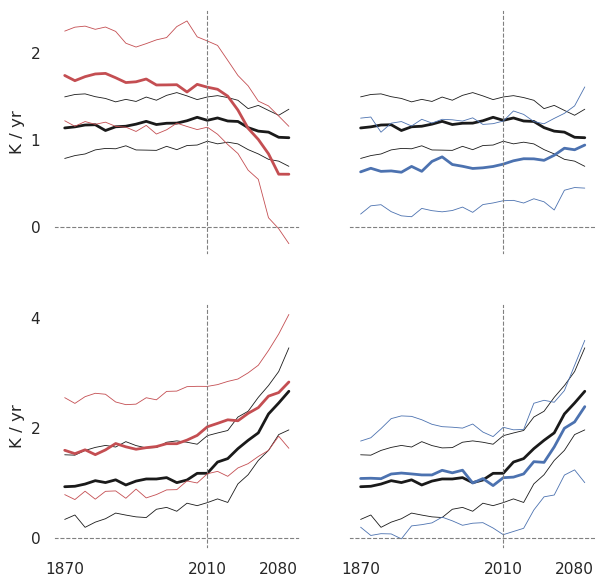

In [14]:
## extract R
# sel_month = lambda x : x.sel(month=slice(10, 12)).mean("month")
sel_month = lambda x: x.sel(month=slice(10, 12)).mean("month")
sel_R = lambda x: 12 * sel_month(x["ddt_T_34"].isel(j=0))
sel_F1 = lambda x: 12 * sel_month(x["ddt_T_34"].isel(j=1))

fig, axs = plt.subplots(2, 2, figsize=(7, 7))

## loop thru R and F1
for j, fn in enumerate([sel_R, sel_F1]):

    ## loop thru pos and negative
    for i, (coef, color) in enumerate(zip([R_F1_pos, R_F1_neg], ["r", "b"])):

        ## plot neutral and pos/or neg
        for R_F1_, color_ in zip([R_F1, coef], ["k", color]):

            ## plot median and bounds
            for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

                ## finally, plot data
                axs[j, i].plot(
                    R_F1_.year, fn(R_F1_).quantile(q=q, dim="member"), c=color_, lw=lw
                )


## formatting
for ax in axs.flatten():
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axvline(2010, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    ax.set_xticks([])
    ax.set_yticks([])
src.utils.set_lims(axs[0])
src.utils.set_lims(axs[1])

for ax in axs[1]:
    ax.set_xticks([1870, 2010, 2080])

axs[0, 0].set_yticks([0, 1, 2])
axs[1, 0].set_yticks([0, 2, 4])
for ax in axs[:, 0]:
    ax.set_ylabel("K / yr")

plt.show()

#### Plot all terms

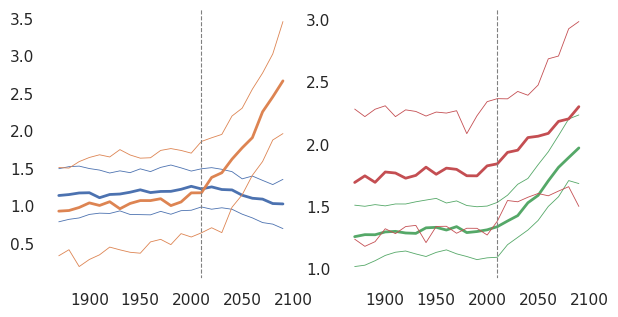

In [15]:
sel = lambda x: x.sel(month=slice(10, 12)).mean("month")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

for j in [0, 1]:
    c = sns.color_palette()[j]
    for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

        ## ddt_T
        c = sns.color_palette()[j]
        plot_data = 12 * sel(R_F1["ddt_T_34"]).quantile(q=q, dim="member").isel(j=j)
        axs[0].plot(R_F1.year, plot_data, c=c, lw=lw)

        ## ddt_h
        c = sns.color_palette()[j + 2]
        plot_data = -12 * sel(R_F1["ddt_h_w"]).quantile(q=q, dim="member").isel(j=j)
        axs[1].plot(R_F1.year, plot_data, c=c, lw=lw)

for ax in axs:
    ax.axvline(2010, ls="--", c="gray", lw=0.8)
    # ax.set_ylim([0,None])

plt.show()
# ax.plot(R_F1.year, sel(R_F1).isel(j=1))

#### Scatter plots

T_34


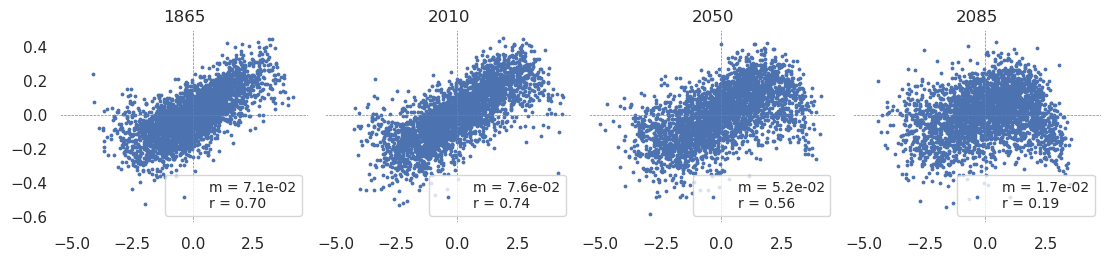

h_w


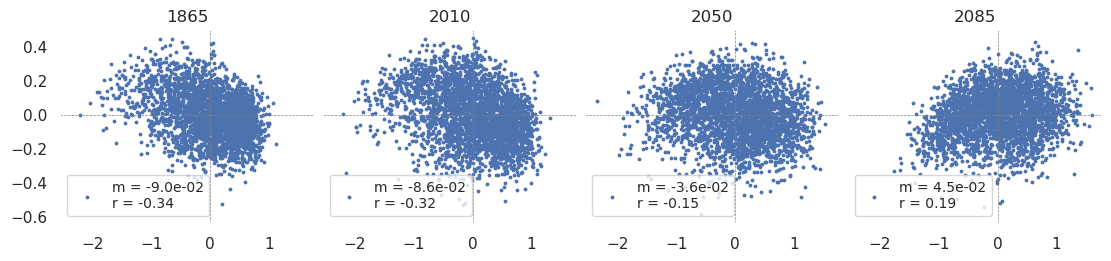

In [16]:
## specify kwargs
kwargs = dict(anom_=anom_, yvar="ddt_T_34", month=10)

for v in ["T_34", "h_w"]:
    print(v)
    fig, axs = make_scatter(xvar=v, **kwargs)
    plt.show()

### Damping

#### Compute

In [17]:
## compute nhf (W/m2)
nhf = src.utils.reconstruct_wrapper(anom[["nhf", "nhf_comp"]], fn=src.utils.get_nino34)[
    "nhf"
]

## convert to damping rate (units of K/mo)
sec_per_mo = 8.64e4 * 30
rho = 1.02e3
Cp = 4.2e3
H0 = 50
Q = nhf * sec_per_mo / (rho * Cp * H0)

## get data for regression
alpha_data = xr.merge([Q.rename("Q"), anom[["T_3", "T_34"]]])

## specify kwargs
regress_kwargs = dict(x_vars=["T_34"], y_vars=["Q"], dims=DIMS)
reduce = lambda x: x["Q"].squeeze(drop=True)
regress_helper = lambda x: reduce(regress_over_time(x, **regress_kwargs))

## do the regression
alpha_all = regress_helper(alpha_data)
alpha_pos = regress_helper(alpha_data.where(alpha_data["T_34"] > 0))
alpha_neg = regress_helper(alpha_data.where(alpha_data["T_34"] < 0))

## merge into single dataarray
alpha = xr.merge(
    [alpha_all.rename("all"), alpha_pos.rename("pos"), alpha_neg.rename("neg")]
)

100%|██████████| 23/23 [00:02<00:00,  9.10it/s]


#### Timeseries

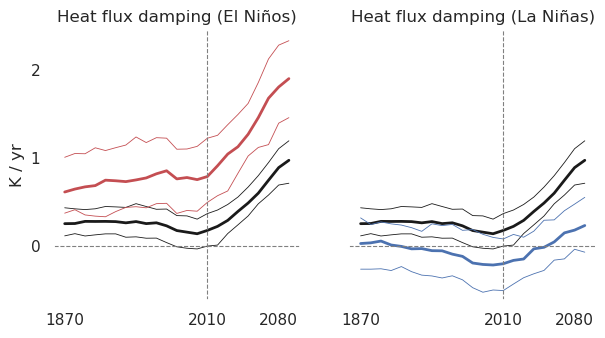

In [18]:
fig, axs = plot_timeseries(
    coefs=alpha, sel_fn=lambda x: -12 * x.sel(month=slice(10, 12)).mean("month")
)

## formatting
axs[0].set_yticks([0, 1, 2])
axs[0].set_title("Heat flux damping (El Niños)")
axs[1].set_title("Heat flux damping (La Niñas)")
axs[0].set_ylabel("K / yr")

plt.show()

#### Scatter plot

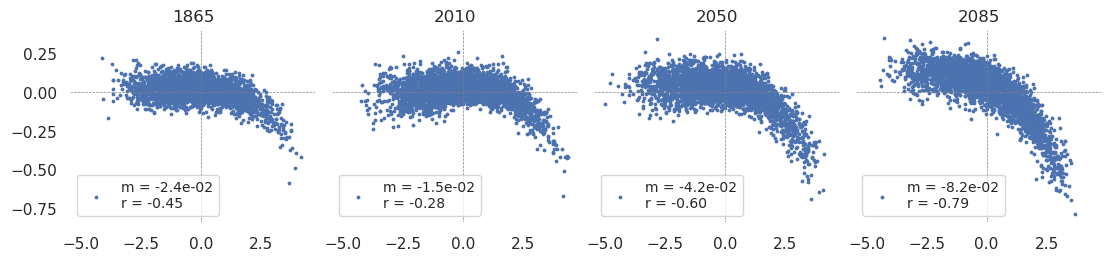

In [19]:
## specify kwargs
kwargs = dict(anom_=alpha_data, xvar="T_34", yvar="Q", month=10, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

#### Spatial plot: for each period, plot spatial structure of warm/cold

In [20]:
def postprocess(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, anom["nhf_comp"]]),
        fn=lambda x: x.sel(longitude=slice(140, 280), latitude=slice(-5, 5)).mean(
            "latitude"
        ),
    )

    ## drop extra variables
    coefs_ = coefs_["nhf"].squeeze(drop=True)

    ## convert to heat flux
    sec_per_mo = 8.64e4 * 30
    rho = 1.02e3
    Cp = 4.2e3
    H0 = 50
    Q = coefs_ * sec_per_mo / (rho * Cp * H0)

    return Q

In [21]:
## get data for regression
alpha_data = xr.merge([anom["nhf"].rename("nhf"), anom[["T_3", "T_34"]]])

## specify kwargs
regress_kwargs = dict(x_vars=["T_34"], y_vars=["nhf"], dims=DIMS)
regress_helper = lambda x: postprocess(regress_over_time(x, **regress_kwargs))

## do the regression
Q_all = regress_helper(alpha_data)
Q_pos = regress_helper(alpha_data.where(alpha_data["T_34"] > 0))
Q_neg = regress_helper(alpha_data.where(alpha_data["T_34"] < 0))

## merge into single dataarray
Q = xr.merge([Q_all.rename("all"), Q_pos.rename("pos"), Q_neg.rename("neg")])

100%|██████████| 23/23 [00:10<00:00,  2.12it/s]


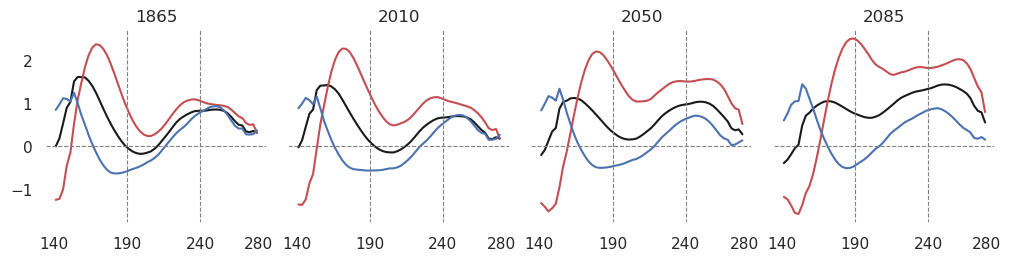

In [22]:
sel = lambda x: -12 * x.sel(month=slice(10, 12)).mean("month")
fig, axs = plot_zonal_structure(coefs=Q, sel_fn=sel)

add_vticks(axs, xticks=[140, 190, 240, 280], xlines=[190, 240])

plt.show()

### wind stress

#### Compute

In [23]:
def postprocess(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, anom["taux_comp"]]),
        fn=lambda x: x.sel(longitude=slice(140, 280), latitude=slice(-5, 5)).mean(
            "latitude"
        ),
    )

    ## drop extra variables
    mu = coefs_["taux"].squeeze(drop=True)

    return mu

In [24]:
## get data for regression
mu_data = xr.merge([anom["taux"], anom[["T_3", "T_34"]]])

## specify kwargs
regress_kwargs = dict(x_vars=["T_34"], y_vars=["taux"], dims=DIMS)
regress_helper = lambda x: postprocess(regress_over_time(x, **regress_kwargs))

## do the regression
mu_all = regress_helper(mu_data)
mu_pos = regress_helper(mu_data.where(mu_data["T_34"] > 0))
mu_neg = regress_helper(mu_data.where(mu_data["T_34"] < 0))

## merge into single dataarray
mu = xr.merge([mu_all.rename("all"), mu_pos.rename("pos"), mu_neg.rename("neg")])

100%|██████████| 23/23 [00:10<00:00,  2.12it/s]


#### Plot zonal structure

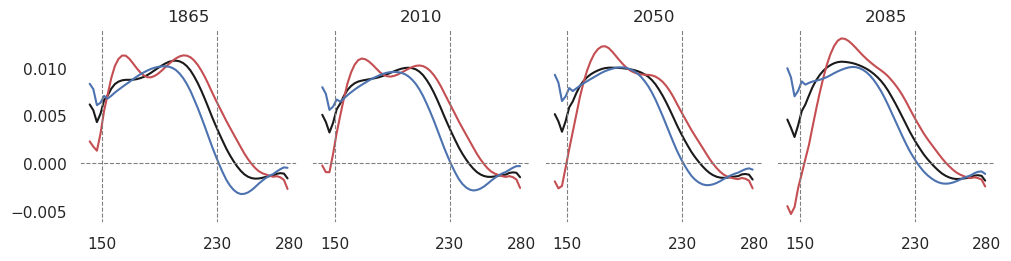

In [25]:
## specify months
MONTHS = [10, 11, 12]

## sel
sel = lambda x: x.sel(month=MONTHS).mean("month")

## plot
fig, axs = plot_zonal_structure(coefs=mu, sel_fn=sel)

## formatting
add_vticks(axs, xticks=[150, 230, 280], xlines=[150, 230])

plt.show()

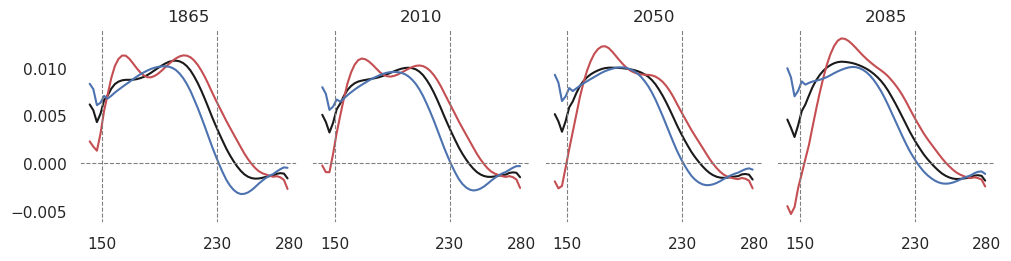

In [26]:
## specify months
MONTHS = [10, 11, 12]
# MONTHS = [1,2,3]

## sel
sel = lambda x: x.sel(month=MONTHS).mean("month")

fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

    ## get data for year
    ax.set_title(y)
    mu_y = sel(mu).sel(year=y, method="nearest")

    ## select data
    for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

        ax.plot(mu.longitude, mu_y[n].mean("member"), c=color)

src.utils.set_lims(axs)
for ax in axs[1:]:
    ax.set_yticks([])

for ax in axs:
    ax.set_xticks([150, 230, 280])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axhline(0, **ax_kwargs)
    for t in [150, 230]:
        ax.axvline(t, **ax_kwargs)

plt.show()

#### Scatter plot

In [27]:
def get_taux_w(taux):
    """compute taux over west/central Pacific"""

    ## make sure latitude is in taux
    if "latitude" in taux.dims:
        taux_ = copy.deepcopy(taux)
    else:
        taux_ = taux.expand_dims("latitude")

    ## specify averaging range
    idx = dict(longitude=slice(150, 230), latitude=slice(-5, 5))

    ## compute
    return taux_.sel(idx).mean(["longitude", "latitude"])


## add to dataarray
mu_data["taux_w"] = src.utils.reconstruct_wrapper(
    anom[["taux", "taux_comp"]],
    fn=get_taux_w,
)["taux"]

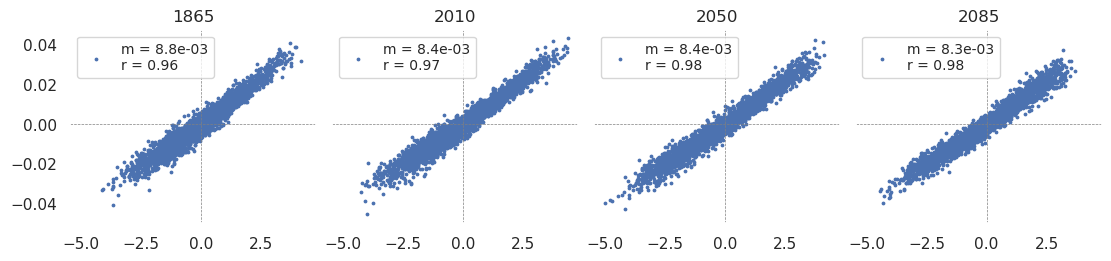

In [28]:
## specify kwargs
kwargs = dict(anom_=mu_data, xvar="T_34", yvar="taux_w", month=10, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

#### Timeseries

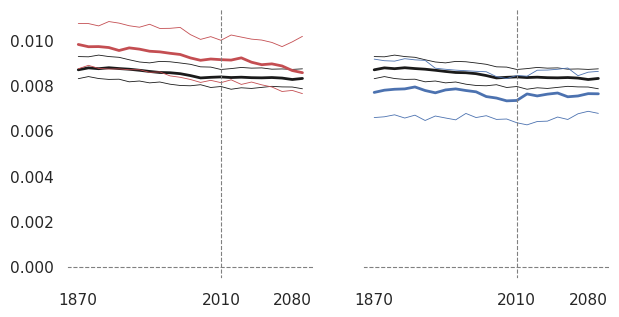

In [29]:
## extract R
sel = lambda x: get_taux_w(x).sel(month=slice(10, 12)).mean("month")

fig, axs = plot_timeseries(coefs=mu, sel_fn=sel)

plt.show()

### Sverdrup balance

#### Compute

In [30]:
def reduce_over_lats(x):
    """reduce over lat/lon/depth"""

    ## specify indices
    idx = dict(longitude=slice(120, 280), latitude=slice(-5, 5))

    ## average over lats
    x_ = x.sel(idx).mean("latitude")

    ## integrate (optionally)
    if len(x_.z_t)>1:
        x_ = x_.integrate("z_t")/300
    else:
        x_ = x_.squeeze(drop=True)
    
    return x_

def postprocess_(coefs, T_var):
    """post-process regression coefficients"""

    ## get recon components
    comps = check_dims(anom[f"{T_var}_comp"])

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, comps]),
        fn=reduce_over_lats,
    )

    ## drop extra variables
    mu = coefs_[T_var].squeeze(drop=True)

    return mu

In [31]:
## specify h-variable (one of "T", "ssh")
y_var = "T"
# h_var = "ssh"

## get data for regression (OHC)
beta_data = xr.merge([anom[y_var], mu_data[["taux_w"]]])
regress_kwargs = dict(x_vars=["taux_w"], y_vars=[y_var], dims=DIMS)
regress_helper = lambda x: postprocess_(regress_over_time(x, **regress_kwargs), T_var=y_var)

## do the regression
beta_all = regress_helper(beta_data)
beta_pos = regress_helper(beta_data.where(mu_data["taux_w"] > 0))
beta_neg = regress_helper(beta_data.where(mu_data["taux_w"] < 0))

## merge into single dataarray
beta = xr.merge(
    [beta_all.rename("all"), beta_pos.rename("pos"), beta_neg.rename("neg")]
)

100%|██████████| 23/23 [00:08<00:00,  2.58it/s]


#### spatial plot

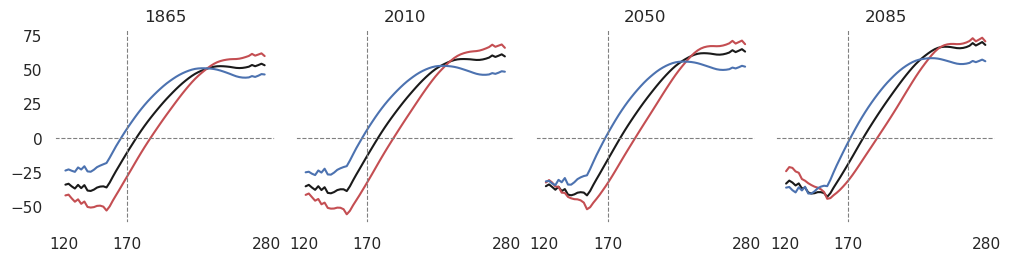

In [32]:
## specify months
MONTHS = [10, 11, 12]
# MONTHS = [1,2,3]

## sel
sel = lambda x: x.sel(month=MONTHS).mean("month")

fig, axs = plot_zonal_structure(coefs=beta, sel_fn=sel)

add_vticks(axs, xticks=[120, 170, 280], xlines=[170])

plt.show()

#### Scatter

##### Compute inices

In [33]:
def reduce(x):
    """reduce over lat/lon/depth"""
    return x.mean(["latitude","z_t"]).sum("longitude")

def get_he(x):
    """average over eastern Pacific"""

    ## check dimensions are ok
    x_ = check_dims(x)

    ## lats/lons for averaging
    idx = dict(longitude=slice(190, 240), latitude=slice(-5, 5))

    return reduce(x_.sel(idx))

def get_hw(x):
    """average over western Pacific"""

    ## check dimensions are ok
    x_ = check_dims(x)

    ## lats/lons for averaging
    idx = dict(longitude=slice(120, 170), latitude=slice(-5, 5))

    return reduce(x_.sel(idx))

    return

def get_dh(x):
    """east-west difference"""

    return get_he(x) - get_hw(x)

In [34]:
# add to dataarray
for n, fn in zip(["he","hw","dh"], [get_he, get_hw, get_dh]):
    beta_data[n] = src.utils.reconstruct_wrapper(
        anom[[y_var, f"{y_var}_comp"]],
        fn=fn,
    )[y_var]

##### Make plot

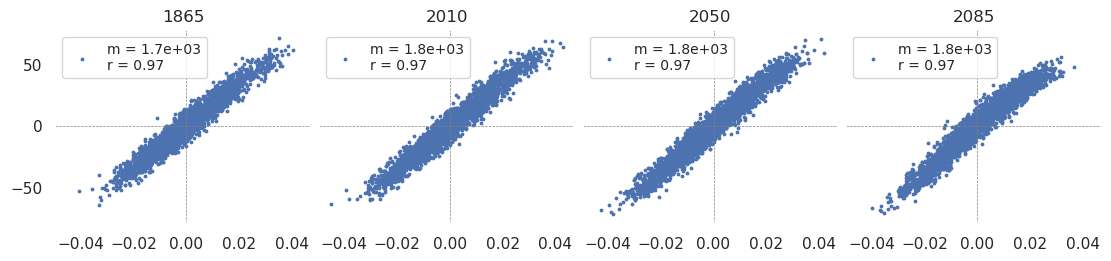

In [47]:
## specify kwargs
kwargs = dict(anom_=beta_data, xvar="taux_w", yvar="dh", month=10, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

#### Timeseries

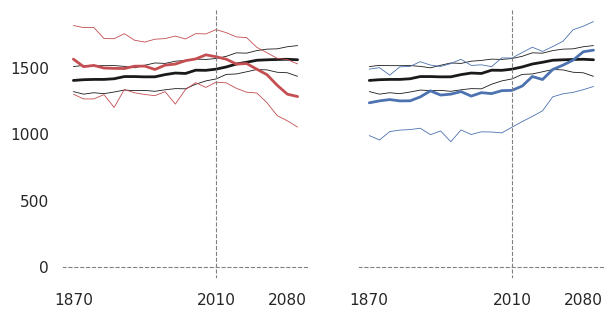

In [36]:
## extract R
sel = lambda x: get_dh(x).sel(month=slice(10, 12)).mean("month")

fig, axs = plot_timeseries(coefs=beta, sel_fn=sel)
plt.show()

### Thermal expansion

#### Compute

In [37]:
def postprocess_Tsub(coefs):
    """post-process regression coefficients"""

    ## get indices
    idx = dict(longitude=slice(120, 280), z_t=slice(50, 70))

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, anom["T_comp"]]),
        fn=lambda x: x.sel(idx).mean("z_t"),
    )

    ## drop extra variables
    mu = coefs_["T"].squeeze(drop=True)

    return mu

In [38]:
## get data for regression
ah_data = xr.merge([anom["T"], beta_data[["he"]]])

In [39]:
regress_kwargs = dict(x_vars=["he"], y_vars=["T"], dims=DIMS)
regress_helper = lambda x: postprocess_Tsub(regress_over_time(x, **regress_kwargs))

## do the regression
ah_all = regress_helper(ah_data)
ah_pos = regress_helper(ah_data.where(ah_data["he"] > 0))
ah_neg = regress_helper(ah_data.where(ah_data["he"] < 0))

## merge into single dataarray
ah = xr.merge([ah_all.rename("all"), ah_pos.rename("pos"), ah_neg.rename("neg")])

100%|██████████| 23/23 [00:08<00:00,  2.59it/s]


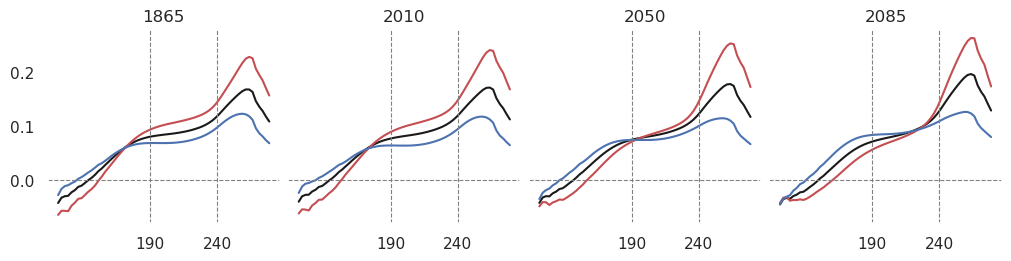

In [40]:
## specify months
MONTHS = [10, 11, 12]

## sel
sel = lambda x: x.sel(month=MONTHS).mean("month")

fig, axs = plot_zonal_structure(coefs=ah, sel_fn=sel)

add_vticks(axs, xticks=[190, 240], xlines=[190, 240])

plt.show()

In [41]:
def get_Tsub(T, lon_range=[190, 240]):
    """compute Tsub over central/east Pacific"""

    ## specify averaging range
    idx = dict(longitude=slice(*lon_range), z_t=slice(50, 70))

    ## compute
    return T.sel(idx).mean(["longitude", "z_t"])


## add to dataarray
ah_data["Tsub"] = src.utils.reconstruct_wrapper(
    anom[["T", "T_comp"]],
    fn=get_Tsub,
)["T"]

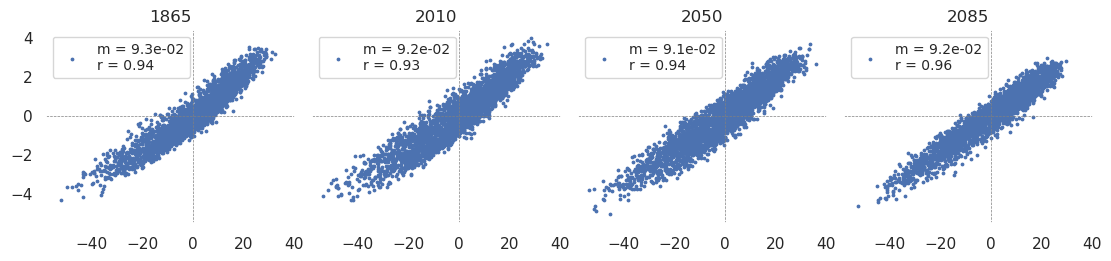

In [42]:
## specify kwargs
kwargs = dict(anom_=ah_data, xvar="he", yvar="Tsub", month=10, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

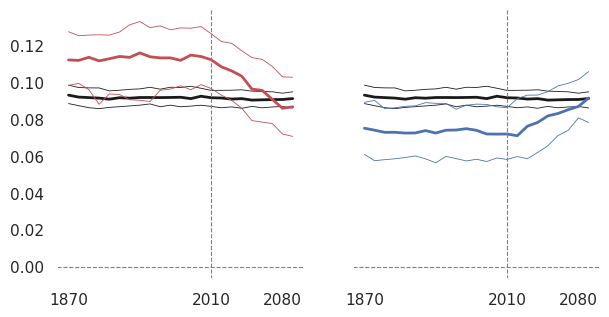

In [43]:
## get index
lon_avg = lambda x : x.sel(longitude=slice(190,240)).mean("longitude")
sel = lambda x: lon_avg(x).sel(month=slice(10, 12)).mean("month")

fig, axs = plot_timeseries(coefs=ah, sel_fn=sel)
plt.show()